In [1]:
import numpy as np
import random
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score


data = load_breast_cancer()
X = data.data
y = data.target
n_features = X.shape[1]


def evaluate(state):
    
    if np.sum(state) == 0:
        return 0
    
    selected_features = np.where(state == 1)[0]
    X_subset = X[:, selected_features]
    
    model = LogisticRegression(max_iter=5000)
    scores = cross_val_score(model, X_subset, y, cv=5)
    return scores.mean()

t)
def generate_neighbors(state):
    neighbors = []
    for i in range(len(state)):
        neighbor = state.copy()
        neighbor[i] = 1 - neighbor[i]  # Flip bit
        neighbors.append(neighbor)
    return neighbors


def hill_climb():
    
    current_state = np.random.randint(0, 2, n_features)
    current_score = evaluate(current_state)
    
    while True:
        neighbors = generate_neighbors(current_state)
        scores = [(neighbor, evaluate(neighbor)) for neighbor in neighbors]
        
        best_neighbor, best_score = max(scores, key=lambda x: x[1])
        
        if best_score > current_score:
            current_state = best_neighbor
            current_score = best_score
        else:
            break
    
    return current_state, current_score


n_runs = 5
results = []

for i in range(n_runs):
    state, score = hill_climb()
    results.append((state, score))
    print(f"Run {i+1}: Accuracy = {score:.4f}, Selected Features = {np.sum(state)}")


best_state, best_score = max(results, key=lambda x: x[1])
print("\nBest overall result:")
print(f"Accuracy: {best_score:.4f}")
print(f"Selected Features: {np.sum(best_state)}")


Run 1: Accuracy = 0.9578, Selected Features = 13
Run 2: Accuracy = 0.9543, Selected Features = 18
Run 3: Accuracy = 0.9508, Selected Features = 13
Run 4: Accuracy = 0.9561, Selected Features = 14
Run 5: Accuracy = 0.9543, Selected Features = 16

Best overall result:
Accuracy: 0.9578
Selected Features: 13


Best route found: [5, 3, 1, 6, 10, 14, 2, 7, 13, 8, 11, 9, 4, 12]
Best total distance: 3.9566


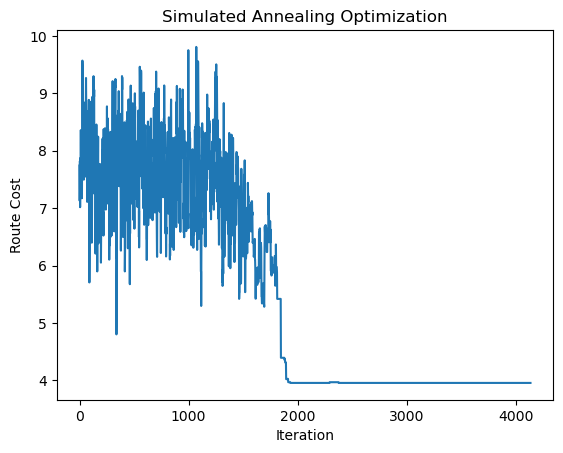

In [2]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt


np.random.seed(42)
n_locations = 15

# First location is depot
locations = np.random.rand(n_locations, 2)

def distance(a, b):
    return np.linalg.norm(a - b)

def total_distance(route):
    total = 0
    depot = locations[0]
    
  
    total += distance(depot, locations[route[0]])
    
    for i in range(len(route) - 1):
        total += distance(locations[route[i]], locations[route[i+1]])
    
  
    total += distance(locations[route[-1]], depot)
    
    return total


def get_neighbor(route):
    new_route = route.copy()
    i, j = random.sample(range(len(route)), 2)
    new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route


def simulated_annealing(T0=1000, alpha=0.995, max_iter=5000):
    
    
    current_route = list(range(1, n_locations))
    random.shuffle(current_route)
    
    current_cost = total_distance(current_route)
    best_route = current_route.copy()
    best_cost = current_cost
    
    T = T0
    costs = []
    
    for t in range(max_iter):
        
        neighbor = get_neighbor(current_route)
        neighbor_cost = total_distance(neighbor)
        
        delta_E = neighbor_cost - current_cost
        
        
        if delta_E < 0:
            current_route = neighbor
            current_cost = neighbor_cost
        else:
            prob = math.exp(-delta_E / T)
            if random.random() < prob:
                current_route = neighbor
                current_cost = neighbor_cost
        
      
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost
        
        costs.append(current_cost)
        
   
        T *= alpha
        
        if T < 1e-6:
            break
    
    return best_route, best_cost, costs


best_route, best_cost, costs = simulated_annealing()

print("Best route found:", best_route)
print("Best total distance:", round(best_cost, 4))

plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Route Cost")
plt.title("Simulated Annealing Optimization")
plt.show()



Best path fitness: 164.0632751703968


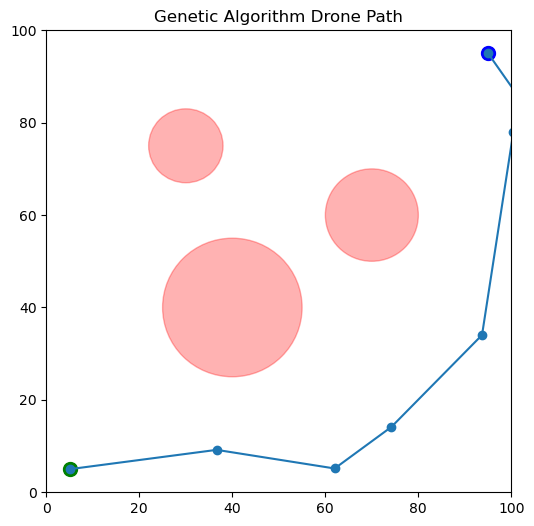

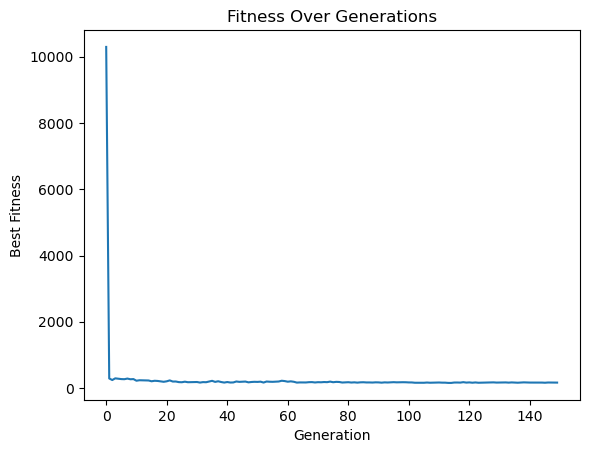

In [3]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

# ----------------------------
# Environment Setup
# ----------------------------
MAP_SIZE = 100
START = np.array([5, 5])
END = np.array([95, 95])
N_WAYPOINTS = 6
POP_SIZE = 60
GENERATIONS = 150
MUTATION_RATE = 0.2
TOURNAMENT_SIZE = 3
PENALTY = 10000

# Define circular obstacles (x, y, radius)
OBSTACLES = [
    (40, 40, 15),
    (70, 60, 10),
    (30, 75, 8)
]

# ----------------------------
# Utility Functions
# ----------------------------
def distance(a, b):
    return np.linalg.norm(a - b)

def line_intersects_circle(p1, p2, circle):
    cx, cy, r = circle
    d = p2 - p1
    f = p1 - np.array([cx, cy])

    a = np.dot(d, d)
    b = 2 * np.dot(f, d)
    c = np.dot(f, f) - r**2

    discriminant = b**2 - 4*a*c
    return discriminant >= 0

# ----------------------------
# Fitness Function
# ----------------------------
def fitness(individual):
    path = [START] + individual + [END]
    total_length = 0
    penalty = 0
    
    for i in range(len(path)-1):
        total_length += distance(path[i], path[i+1])
        
        for obs in OBSTACLES:
            if line_intersects_circle(path[i], path[i+1], obs):
                penalty += PENALTY
                
    return total_length + penalty

# ----------------------------
# Population Initialization
# ----------------------------
def random_waypoint():
    return np.array([
        random.uniform(0, MAP_SIZE),
        random.uniform(0, MAP_SIZE)
    ])

def initialize_population():
    population = []
    for _ in range(POP_SIZE):
        individual = [random_waypoint() for _ in range(N_WAYPOINTS)]
        population.append(individual)
    return population

# ----------------------------
# Selection (Tournament)
# ----------------------------
def tournament_selection(population):
    competitors = random.sample(population, TOURNAMENT_SIZE)
    competitors.sort(key=lambda ind: fitness(ind))
    return competitors[0]

# ----------------------------
# Crossover (One-point)
# ----------------------------
def crossover(parent1, parent2):
    point = random.randint(1, N_WAYPOINTS-1)
    child = parent1[:point] + parent2[point:]
    return child

# ----------------------------
# Mutation (Coordinate Perturbation)
# ----------------------------
def mutate(individual):
    for i in range(N_WAYPOINTS):
        if random.random() < MUTATION_RATE:
            individual[i] += np.random.normal(0, 5, size=2)
            individual[i] = np.clip(individual[i], 0, MAP_SIZE)
    return individual

# ----------------------------
# Genetic Algorithm
# ----------------------------
def genetic_algorithm():
    population = initialize_population()
    best_fitness_progress = []
    
    for gen in range(GENERATIONS):
        new_population = []
        
        for _ in range(POP_SIZE):
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)
            
            child = crossover(parent1, parent2)
            child = mutate(child)
            
            new_population.append(child)
        
        population = new_population
        
        best = min(population, key=lambda ind: fitness(ind))
        best_fitness_progress.append(fitness(best))
    
    best_solution = min(population, key=lambda ind: fitness(ind))
    return best_solution, best_fitness_progress

# ----------------------------
# Run GA
# ----------------------------
best_path, fitness_progress = genetic_algorithm()

print("Best path fitness:", fitness(best_path))

# ----------------------------
# Visualization
# ----------------------------
plt.figure(figsize=(6,6))

# Plot obstacles
for (x, y, r) in OBSTACLES:
    circle = plt.Circle((x, y), r, color='red', alpha=0.3)
    plt.gca().add_patch(circle)

# Plot path
full_path = [START] + best_path + [END]
xs = [p[0] for p in full_path]
ys = [p[1] for p in full_path]
plt.plot(xs, ys, marker='o')

plt.scatter(*START, color='green', s=100)
plt.scatter(*END, color='blue', s=100)

plt.xlim(0, MAP_SIZE)
plt.ylim(0, MAP_SIZE)
plt.title("Genetic Algorithm Drone Path")
plt.show()

# Plot convergence
plt.plot(fitness_progress)
plt.title("Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.show()
